In [2]:
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Explicit path — works regardless of where Jupyter was launched from
ROOT = Path(r"C:\Users\DELL\Downloads\certificates\major_project_docs\password-security-project")
sys.path.insert(0, str(ROOT))

from preprocessing.feature_extraction import extract_feature_vector, FEATURE_NAMES
from preprocessing.label_generator import label_password
from generator.password_gen import score_password

# Load both models
with open(ROOT / "models/strength_model.pkl", "rb") as f:
    strength_model = pickle.load(f)
with open(ROOT / "models/memorability_model.pkl", "rb") as f:
    memorability_model = pickle.load(f)

print("Models loaded successfully")
print(f"Strength model:     {type(strength_model).__name__}")
print(f"Memorability model: {type(memorability_model).__name__}")

Models loaded successfully
Strength model:     RandomForestClassifier
Memorability model: RandomForestClassifier


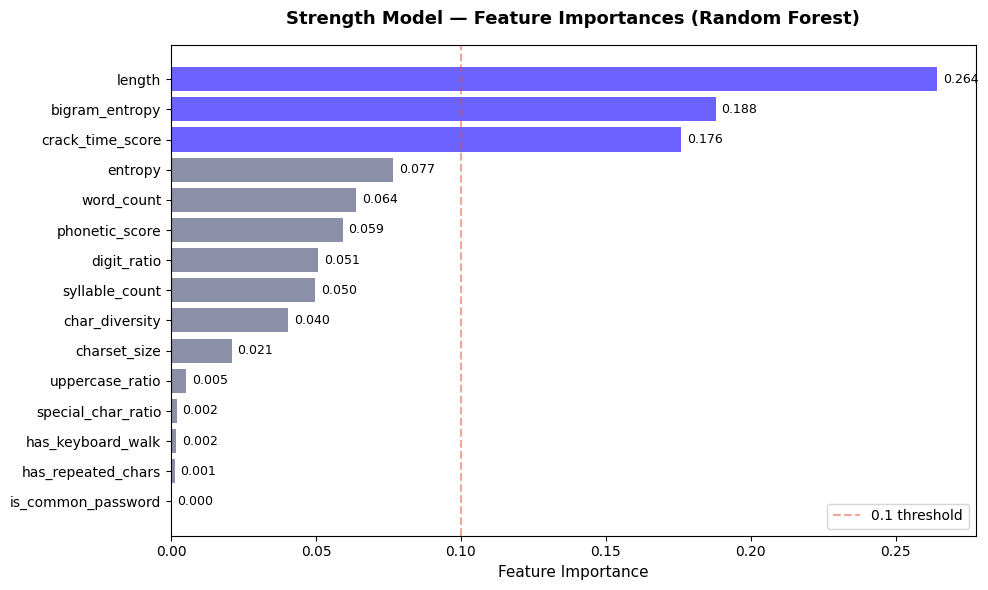

Top 3 features: ['length', 'bigram_entropy', 'crack_time_score']


In [5]:
# Create notebooks folder if it doesn't exist
(ROOT / "notebooks").mkdir(exist_ok=True)
fig, ax = plt.subplots(figsize=(10, 6))

importances = strength_model.feature_importances_
indices     = np.argsort(importances)[::-1]
sorted_names = [FEATURE_NAMES[i] for i in indices]
sorted_vals  = importances[indices]

colors = ["#6c63ff" if v > 0.1 else "#8b8fa8" for v in sorted_vals]
bars = ax.barh(sorted_names[::-1], sorted_vals[::-1], color=colors[::-1])

ax.set_xlabel("Feature Importance", fontsize=11)
ax.set_title("Strength Model — Feature Importances (Random Forest)", 
             fontsize=13, fontweight="bold", pad=15)
ax.axvline(x=0.1, color="#e74c3c", linestyle="--", alpha=0.5, label="0.1 threshold")
ax.legend()

for bar, val in zip(bars, sorted_vals[::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(ROOT / "notebooks/strength_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Top 3 features:", sorted_names[:3])

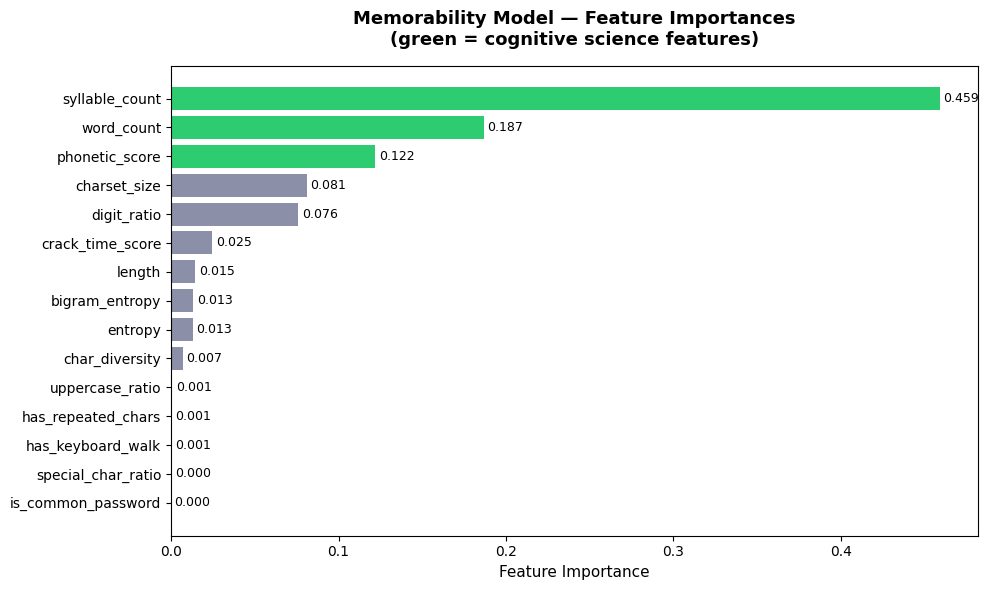

Key cognitive features:
  syllable_count         0.4590
  word_count             0.1870
  phonetic_score         0.1221
  charset_size           0.0813
  digit_ratio            0.0761


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

importances = memorability_model.feature_importances_
indices     = np.argsort(importances)[::-1]
sorted_names = [FEATURE_NAMES[i] for i in indices]
sorted_vals  = importances[indices]

colors = ["#2ecc71" if n in ["syllable_count","phonetic_score","word_count"] 
          else "#8b8fa8" for n in sorted_names]
colors_r = colors[::-1]

bars = ax.barh(sorted_names[::-1], sorted_vals[::-1], color=colors_r)

ax.set_xlabel("Feature Importance", fontsize=11)
ax.set_title("Memorability Model — Feature Importances\n(green = cognitive science features)", 
             fontsize=13, fontweight="bold", pad=15)

for bar, val in zip(bars, sorted_vals[::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(ROOT / "notebooks/memorability_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Key cognitive features:")
for name, val in zip(sorted_names[:5], sorted_vals[:5]):
    print(f"  {name:<22} {val:.4f}")

In [7]:
test_passwords = [
    ("123456",                 "Weak, common"),
    ("password",               "Dictionary word"),
    ("P@ssw0rd",               "Classic substitution"),
    ("correct-horse-battery",  "Passphrase (XKCD)"),
    ("xK9!mPq2Tz@W",          "Random strong"),
    ("Mumbai@2019!Chai",       "Personal phrase"),
    ("BrunoD0g2024!",          "Transformed phrase"),
    ("Tr0ub4dor&3",            "Complex substitution"),
]

rows = []
for pwd, desc in test_passwords:
    s = score_password(pwd)
    rows.append({
        "Password":     pwd,
        "Description":  desc,
        "Strength":     s["strength_label"],
        "Str. Prob":    f"{s['strength_proba']:.2f}",
        "Memorability": s["memorability_label"],
        "Mem. Prob":    f"{s['memorability_proba']:.2f}",
        "Score":        f"{s['combined_score']:.2f}",
    })

df = pd.DataFrame(rows)

def colour_strength(val):
    colors = {"strong": "background-color: #1a3a2a; color: #2ecc71",
              "medium": "background-color: #3a2e1a; color: #f39c12",
              "weak":   "background-color: #3a1a1a; color: #e74c3c"}
    return colors.get(val, "")

def colour_mem(val):
    return ("background-color: #1a2a3a; color: #3b82f6"
            if val == "memorable" else
            "background-color: #2a1a2a; color: #9333ea")

styled = (df.style
    .applymap(colour_strength, subset=["Strength"])
    .applymap(colour_mem,      subset=["Memorability"])
    .set_caption("ML Scoring Results — PassGuard System")
    .set_properties(**{"font-size": "11px"}))

display(styled)

,Password,Description,Strength,Str. Prob,Memorability,Mem. Prob,Score
0,123456,"Weak, common",weak,0.00,not_memorable,0.10,0.04
1,password,Dictionary word,weak,0.00,memorable,0.99,0.40
2,P@ssw0rd,Classic substitution,weak,0.00,not_memorable,0.10,0.04
3,correct-horse-battery,Passphrase (XKCD),strong,0.70,memorable,0.99,0.82
4,xK9!mPq2Tz@W,Random strong,weak,0.10,not_memorable,0.15,0.12
5,Mumbai@2019!Chai,Personal phrase,strong,0.49,memorable,0.98,0.69
6,BrunoD0g2024!,Transformed phrase,medium,0.36,not_memorable,0.10,0.25
7,Tr0ub4dor&3,Complex substitution,weak,0.06,memorable,0.99,0.43


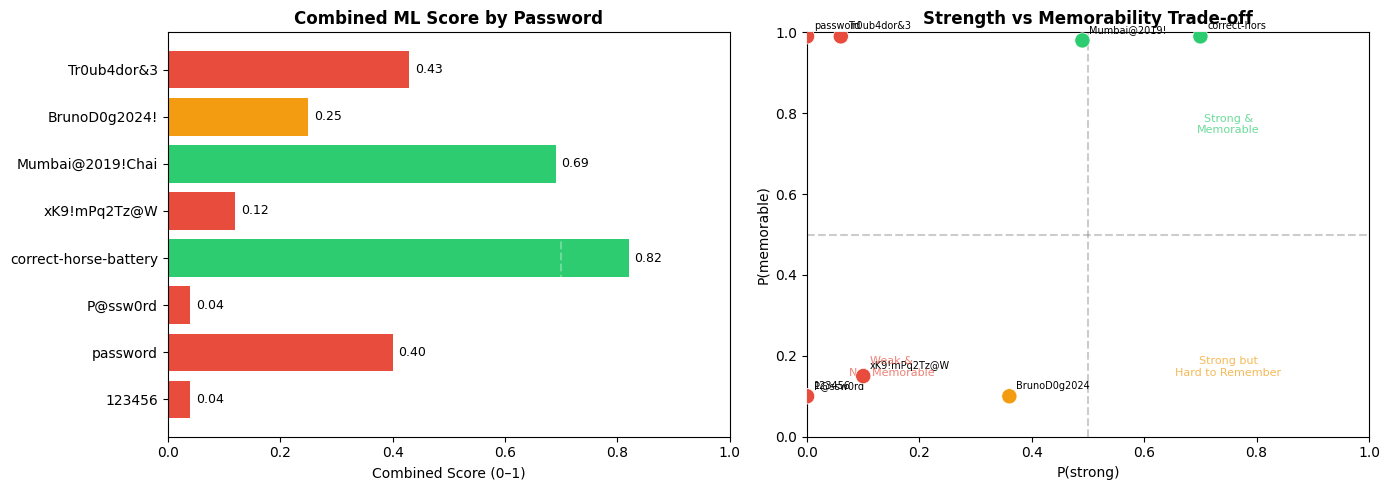

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

passwords = [r["Password"] for r in rows]
scores    = [float(r["Score"]) for r in rows]
strengths = [r["Strength"] for r in rows]
mems      = [r["Memorability"] for r in rows]

str_colors = {"strong": "#2ecc71", "medium": "#f39c12", "weak": "#e74c3c"}
mem_colors = {"memorable": "#3b82f6", "not_memorable": "#9333ea"}

# Combined score bar chart
bar_colors = [str_colors[s] for s in strengths]
bars = axes[0].barh(passwords, scores, color=bar_colors)
axes[0].set_xlim(0, 1)
axes[0].set_xlabel("Combined Score (0–1)")
axes[0].set_title("Combined ML Score by Password", fontweight="bold")
axes[0].axvline(x=0.7, color="white", linestyle="--", alpha=0.3, label="0.7 threshold")
for bar, val in zip(bars, scores):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{val:.2f}", va="center", fontsize=9)

# Scatter: strength vs memorability probability
str_probs = [float(r["Str. Prob"]) for r in rows]
mem_probs = [float(r["Mem. Prob"]) for r in rows]
scatter_colors = [str_colors[s] for s in strengths]

scatter = axes[1].scatter(str_probs, mem_probs, 
                          c=scatter_colors, s=120, zorder=5, edgecolors="white", linewidth=0.5)
for i, pwd in enumerate(passwords):
    axes[1].annotate(pwd[:12], (str_probs[i], mem_probs[i]),
                     textcoords="offset points", xytext=(5, 5), fontsize=7)

axes[1].set_xlabel("P(strong)")
axes[1].set_ylabel("P(memorable)")
axes[1].set_title("Strength vs Memorability Trade-off", fontweight="bold")
axes[1].axhline(y=0.5, color="gray", linestyle="--", alpha=0.4)
axes[1].axvline(x=0.5, color="gray", linestyle="--", alpha=0.4)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

# Quadrant labels
axes[1].text(0.75, 0.75, "Strong &\nMemorable", ha="center", fontsize=8, 
             color="#2ecc71", alpha=0.7)
axes[1].text(0.75, 0.15, "Strong but\nHard to Remember", ha="center", fontsize=8,
             color="#f39c12", alpha=0.7)
axes[1].text(0.15, 0.15, "Weak &\nNot Memorable", ha="center", fontsize=8,
             color="#e74c3c", alpha=0.7)

plt.tight_layout()
plt.savefig(ROOT / "notebooks/score_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
print("=" * 55)
print("  PassGuard — Model Performance Summary")
print("=" * 55)

strength_report    = (ROOT / "models/strength_report.txt").read_text()
memorability_report = (ROOT / "models/memorability_report.txt").read_text()

print("\n── Strength Model ─────────────────────────────────")
for line in strength_report.split("\n")[:15]:
    print(line)

print("\n── Memorability Model ─────────────────────────────")
for line in memorability_report.split("\n")[:15]:
    print(line)

print("\n── Key design decisions ───────────────────────────")
print("  Algorithm      : Random Forest (both models)")
print("  Training data  : 100,000 passwords from RockYou")
print("  Evaluation     : 20,000 held-out passwords (never seen in training)")
print("  Labelling      : zxcvbn (independent oracle — prevents data leakage)")
print("  Imbalance fix  : class_weight='balanced'")
print("  Previous bug   : 100% accuracy due to data leakage — now fixed")

  PassGuard — Model Performance Summary

── Strength Model ─────────────────────────────────
Strength Model — Classification Report
Overall Accuracy: 0.8155

              precision    recall  f1-score   support

        weak     0.9856    0.8117    0.8903     17851
      medium     0.3506    0.8531    0.4970      2097
      strong     0.1523    0.5769    0.2410        52

    accuracy                         0.8155     20000
   macro avg     0.4962    0.7473    0.5427     20000
weighted avg     0.9169    0.8155    0.8473     20000

Confusion Matrix:

── Memorability Model ─────────────────────────────
Memorability Model — Classification Report
Overall Accuracy: 1.0000

               precision    recall  f1-score   support

not_memorable     1.0000    1.0000    1.0000      7336
    memorable     1.0000    1.0000    1.0000     12664

     accuracy                         1.0000     20000
    macro avg     1.0000    1.0000    1.0000     20000
 weighted avg     1.0000    1.0000    1.0000